# Data Analysis with SQL, Pandas, and SQLite (Northwind)

This notebook focuses on **data analysis using SQL**, with the help of **pandas** and **matplotlib**.

## 0. Environment Setup

In this section we:
- Import required libraries
- Download the Northwind SQLite database
- Connect to it and inspect the schema

In [170]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Download the sample Northwind SQLite database
!wget -q https://www.timestored.com/data/sample/northwind_small.sqlite -O northwind.sqlite

# Connect to SQLite
conn = sqlite3.connect('northwind.sqlite')
#print('Connected to northwind.sqlite')

'wget' is not recognized as an internal or external command,
operable program or batch file.


### 0.1 Inspect the database

Let's see what tables exist in the database.

In [105]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
tables

,name
0,Category
1,Customer
2,CustomerCustomerDemo
3,CustomerDemographic
4,Employee
5,EmployeeTerritory
6,Order
7,OrderDetail
8,Product
9,Region


## Northwind Database ERD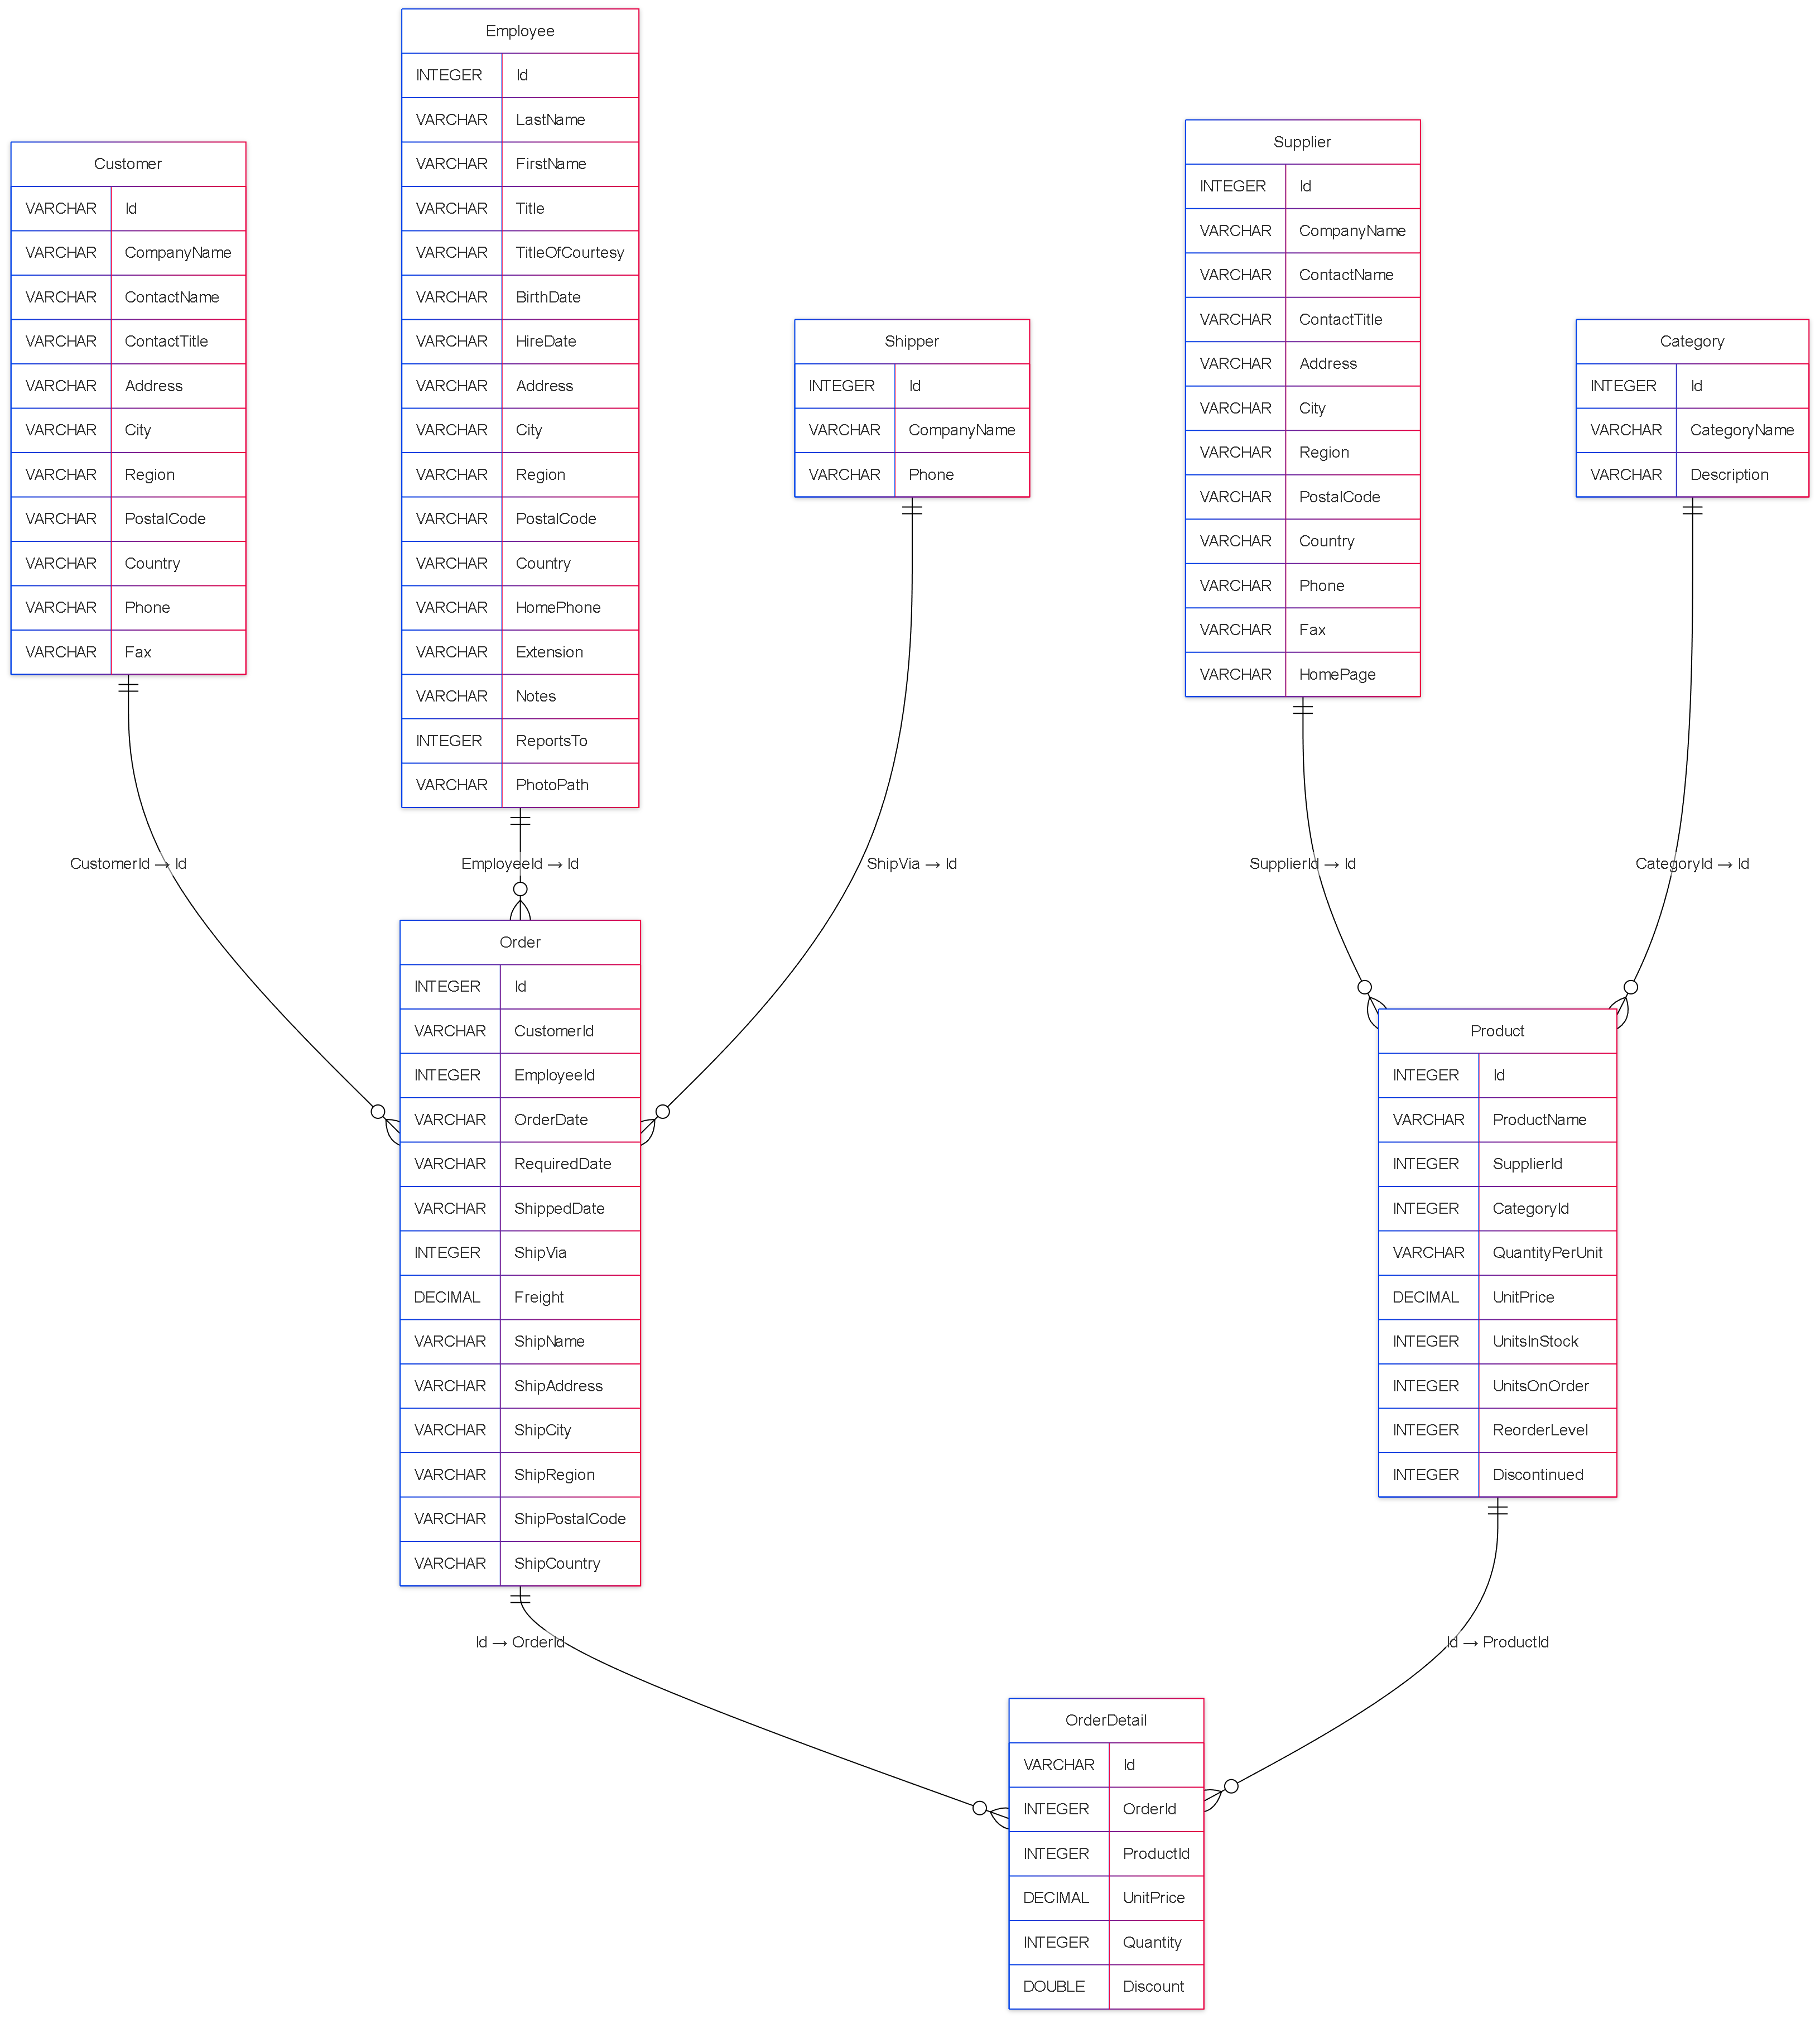

Now let's peek at some key tables: `Customer`, `Employee`, `Order`, `OrderDetail`.

In [106]:
for table in ['Customer', 'Employee', 'Order', 'OrderDetail']:
    print(f"\n=== {table} ===")
    try:
        display(pd.read_sql_query(f'SELECT * FROM "{table}" LIMIT 5;', conn))
    except Exception as e:
        print(f'Error reading {table}:', e)


=== Customer ===


,Id,CompanyName,ContactName,ContactTitle,Address,City,Region,PostalCode,Country,Phone,Fax
0,ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,Western Europe,12209,Germany,030-0074321,030-0076545
1,ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,Central America,05021,Mexico,(5) 555-4729,(5) 555-3745
2,ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,Central America,05023,Mexico,(5) 555-3932,None
3,AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,British Isles,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
4,BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,Northern Europe,S-958 22,Sweden,0921-12 34 65,0921-12 34 67



=== Employee ===


,Id,LastName,FirstName,Title,TitleOfCourtesy,BirthDate,HireDate,Address,City,Region,PostalCode,Country,HomePhone,Extension,Photo,Notes,ReportsTo,PhotoPath
0,1,Davolio,Nancy,Sales Representative,Ms.,1980-12-08,2024-05-01,507 - 20th Ave. E. Apt. 2A,Seattle,North America,98122,USA,(206) 555-9857,5467,None,Education includes a BA in psychology from Col...,2.0,http://accweb/emmployees/davolio.bmp
1,2,Fuller,Andrew,"Vice President, Sales",Dr.,1984-02-19,2024-08-14,908 W. Capital Way,Tacoma,North America,98401,USA,(206) 555-9482,3457,None,Andrew received his BTS commercial in 1974 and...,NaN,http://accweb/emmployees/fuller.bmp
2,3,Leverling,Janet,Sales Representative,Ms.,1995-08-30,2024-04-01,722 Moss Bay Blvd.,Kirkland,North America,98033,USA,(206) 555-3412,3355,None,Janet has a BS degree in chemistry from Boston...,2.0,http://accweb/emmployees/leverling.bmp
3,4,Peacock,Margaret,Sales Representative,Mrs.,1969-09-19,2025-05-03,4110 Old Redmond Rd.,Redmond,North America,98052,USA,(206) 555-8122,5176,None,Margaret holds a BA in English literature from...,2.0,http://accweb/emmployees/peacock.bmp
4,5,Buchanan,Steven,Sales Manager,Mr.,1987-03-04,2025-10-17,14 Garrett Hill,London,British Isles,SW1 8JR,UK,(71) 555-4848,3453,None,Steven Buchanan graduated from St. Andrews Uni...,2.0,http://accweb/emmployees/buchanan.bmp



=== Order ===


,Id,CustomerId,EmployeeId,OrderDate,RequiredDate,ShippedDate,ShipVia,Freight,ShipName,ShipAddress,ShipCity,ShipRegion,ShipPostalCode,ShipCountry
0,10248,VINET,5,2012-07-04,2012-08-01,2012-07-16,3,32.38,Vins et alcools Chevalier,59 rue de l'Abbaye,Reims,Western Europe,51100,France
1,10249,TOMSP,6,2012-07-05,2012-08-16,2012-07-10,1,11.61,Toms Spezialitäten,Luisenstr. 48,Münster,Western Europe,44087,Germany
2,10250,HANAR,4,2012-07-08,2012-08-05,2012-07-12,2,65.83,Hanari Carnes,"Rua do Paço, 67",Rio de Janeiro,South America,05454-876,Brazil
3,10251,VICTE,3,2012-07-08,2012-08-05,2012-07-15,1,41.34,Victuailles en stock,"2, rue du Commerce",Lyon,Western Europe,69004,France
4,10252,SUPRD,4,2012-07-09,2012-08-06,2012-07-11,2,51.30,Suprêmes délices,"Boulevard Tirou, 255",Charleroi,Western Europe,B-6000,Belgium



=== OrderDetail ===


,Id,OrderId,ProductId,UnitPrice,Quantity,Discount
0,10248/11,10248,11,14.0,12,0.0
1,10248/42,10248,42,9.8,10,0.0
2,10248/72,10248,72,34.8,5,0.0
3,10249/14,10249,14,18.6,9,0.0
4,10249/51,10249,51,42.4,40,0.0


## 1. Using Pandas with SQL

### 1.1 `pd.read_sql_query`

The main function we will use is:

```python
pd.read_sql_query(sql, conn)
```

- `sql` is a string containing your SQL query
- `conn` is a SQLite connection (`sqlite3.connect(...)`)
- The result is a **pandas DataFrame**

Example:
```python
sql = "SELECT Id, CompanyName, Country FROM Customer LIMIT 10;"
df = pd.read_sql_query(sql, conn)
df.head()
```

In [107]:
# Example: simple SELECT using pandas + SQL
sql = "SELECT Id, CompanyName, Country FROM Customer LIMIT 10;"
df_customers = pd.read_sql_query(sql, conn)
df_customers

,Id,CompanyName,Country
0,ALFKI,Alfreds Futterkiste,Germany
1,ANATR,Ana Trujillo Emparedados y helados,Mexico
2,ANTON,Antonio Moreno Taquería,Mexico
3,AROUT,Around the Horn,UK
4,BERGS,Berglunds snabbköp,Sweden
5,BLAUS,Blauer See Delikatessen,Germany
6,BLONP,Blondesddsl père et fils,France
7,BOLID,Bólido Comidas preparadas,Spain
8,BONAP,Bon app,France
9,BOTTM,Bottom-Dollar Markets,Canada


### 1.2 Parameterized queries

Sometimes you want to substitute values safely into queries. With SQLite and pandas, you can:

```python
country = 'Germany'
sql = "SELECT * FROM Customer WHERE Country = ?;"
df = pd.read_sql_query(sql, conn, params=[country])
```

This avoids string concatenation and is safer and cleaner.

In [108]:
# Example: parameterized query
country = 'Germany'
sql = "SELECT Id, CompanyName, City, Country FROM Customer WHERE Country = ? LIMIT 10;"
df_germany = pd.read_sql_query(sql, conn, params=[country])
df_germany

,Id,CompanyName,City,Country
0,ALFKI,Alfreds Futterkiste,Berlin,Germany
1,BLAUS,Blauer See Delikatessen,Mannheim,Germany
2,DRACD,Drachenblut Delikatessen,Aachen,Germany
3,FRANK,Frankenversand,München,Germany
4,KOENE,Königlich Essen,Brandenburg,Germany
5,LEHMS,Lehmanns Marktstand,Frankfurt a.M.,Germany
6,MORGK,Morgenstern Gesundkost,Leipzig,Germany
7,OTTIK,Ottilies Käseladen,Köln,Germany
8,QUICK,QUICK-Stop,Cunewalde,Germany
9,TOMSP,Toms Spezialitäten,Münster,Germany


## 2. Sales Metric: `LineTotal`

Most of our analysis will use a basic **sales amount** defined per order line as:

```sql
LineTotal = UnitPrice * Quantity * (1 - Discount)
```

Using:
- `OrderDetail.UnitPrice`
- `OrderDetail.Quantity`
- `OrderDetail.Discount`

We will combine:
- `Order` (for dates, customer, employee, shipping info)
- `OrderDetail` (for line amounts)
- sometimes `Customer` and `Employee` for dimensions like region/country.

## 3. Example Visualizations


### 3.1 Total sales over time (by day)

We'll:
1. Join `Order` and `OrderDetail`
2. Compute `LineTotal`
3. Group by `OrderDate` and sum up totals
4. Load into pandas and plot a time series

In [109]:
sql_total_sales_by_day = """
SELECT
  o.OrderDate,
  -- strftime('%Y-%W', o.OrderDate) AS OrderWeek,
  SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
GROUP BY OrderDate
ORDER BY o.OrderDate;
"""

df_sales_by_day = pd.read_sql_query(sql_total_sales_by_day, conn)
df_sales_by_day

,OrderDate,TotalSales
0,2012-07-04,440.0000
1,2012-07-05,1863.4000
2,2012-07-08,2206.6600
3,2012-07-09,3597.9000
4,2012-07-10,1444.8000
...,...,...
475,2014-04-30,2525.3500
476,2014-05-01,5448.5700
477,2014-05-04,2473.9300
478,2014-05-05,7632.4750


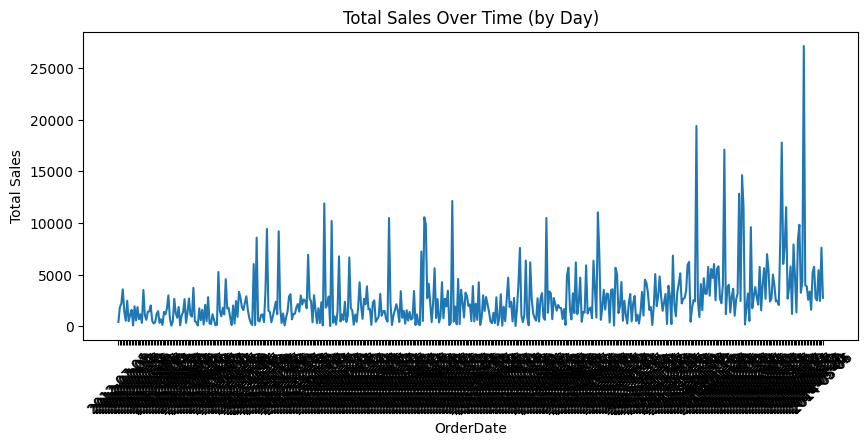

In [110]:
# Plot total sales over time (by day)
plt.figure(figsize=(10, 4))
plt.plot(df_sales_by_day['OrderDate'], df_sales_by_day['TotalSales'])
plt.title('Total Sales Over Time (by Day)')
plt.xlabel('OrderDate')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


### 3.2 Top 10 customers by total sales

Now let's find the **top 10 customers** by total sales.

Steps:
1. Join `Order`, `OrderDetail`, and `Customer`
2. Compute `LineTotal` per order line
3. Group by `CustomerId` (and maybe `CompanyName`)
4. Sort by total sales descending and take top 10
5. Plot a bar chart

In [111]:
sql_top_customers = """
SELECT
  c.Id AS CustomerId,
  c.CompanyName,
  SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
JOIN Customer c ON o.CustomerId = c.Id
GROUP BY c.Id, c.CompanyName
ORDER BY TotalSales DESC
LIMIT 10;
"""

df_top_customers = pd.read_sql_query(sql_top_customers, conn)
df_top_customers

,CustomerId,CompanyName,TotalSales
0,QUICK,QUICK-Stop,110277.3050
1,ERNSH,Ernst Handel,104874.9785
2,SAVEA,Save-a-lot Markets,104361.9500
3,RATTC,Rattlesnake Canyon Grocery,51097.8005
4,HUNGO,Hungry Owl All-Night Grocers,49979.9050
5,HANAR,Hanari Carnes,32841.3700
6,KOENE,Königlich Essen,30908.3840
7,FOLKO,Folk och fä HB,29567.5625
8,MEREP,Mère Paillarde,28872.1900
9,WHITC,White Clover Markets,27363.6050


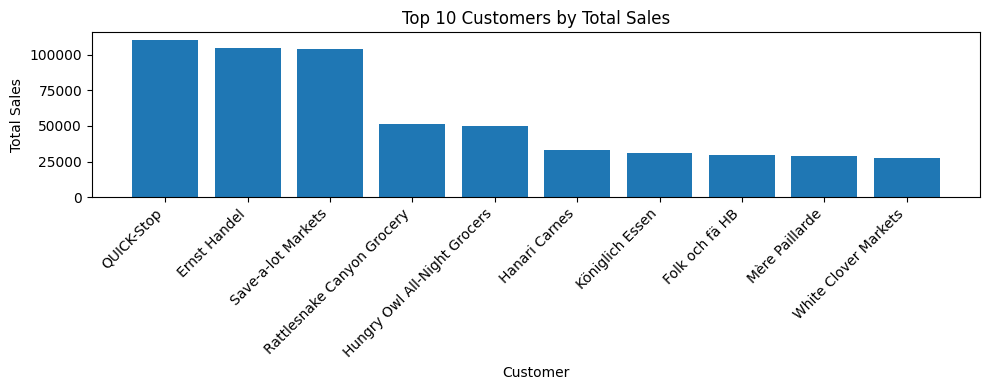

In [112]:
# Plot top 10 customers by total sales
plt.figure(figsize=(10, 4))
plt.bar(df_top_customers['CompanyName'], df_top_customers['TotalSales'])
plt.title('Top 10 Customers by Total Sales')
plt.xlabel('Customer')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.3 Total sales by customer country

Next, let's aggregate sales by **customer country**.

Steps:
1. Same join as before (`Order` + `OrderDetail` + `Customer`)
2. Group by `Customer.Country`
3. Plot the top N countries as a bar chart.

In [113]:
sql_sales_by_country = """
SELECT
  c.Country,
  SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
JOIN Customer c ON o.CustomerId = c.Id
GROUP BY c.Country
ORDER BY TotalSales DESC;
"""

df_sales_by_country = pd.read_sql_query(sql_sales_by_country, conn)
df_sales_by_country.head()

,Country,TotalSales
0,USA,245584.6105
1,Germany,230284.6335
2,Austria,128003.8385
3,Brazil,81208.2790
4,France,79742.4225


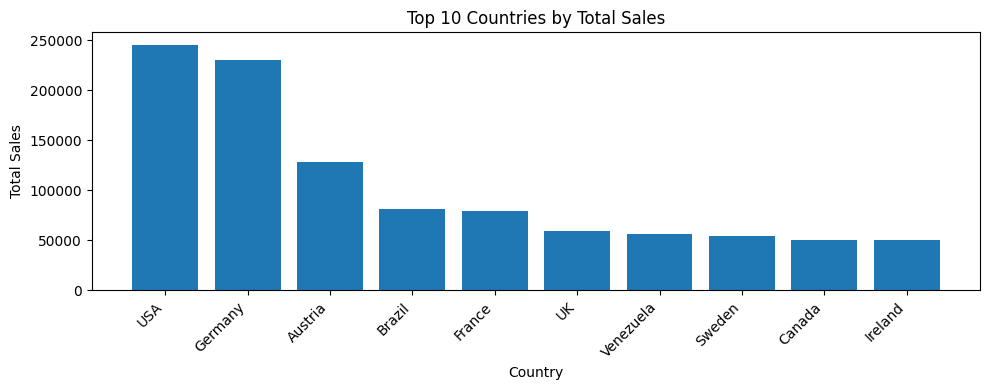

In [114]:
# Plot top 10 countries by total sales
top_n = 10
df_top_countries = df_sales_by_country.head(top_n)

plt.figure(figsize=(10, 4))
plt.bar(df_top_countries['Country'], df_top_countries['TotalSales'])
plt.title(f'Top {top_n} Countries by Total Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.4 Monthly total sales

We can also **resample** sales by month. In SQLite, we can use `strftime` to extract year-month:

```sql
strftime('%Y-%m', OrderDate) AS YearMonth
```

We then group by this `YearMonth` and plot.

In [115]:
sql_sales_by_month = """
SELECT
  strftime('%Y-%m', o.OrderDate) AS YearMonth,
  SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
GROUP BY YearMonth
ORDER BY YearMonth;
"""

df_sales_by_month = pd.read_sql_query(sql_sales_by_month, conn)
df_sales_by_month.head()

,YearMonth,TotalSales
0,2012-07,27861.895
1,2012-08,25485.275
2,2012-09,26381.400
3,2012-10,37515.725
4,2012-11,45600.045


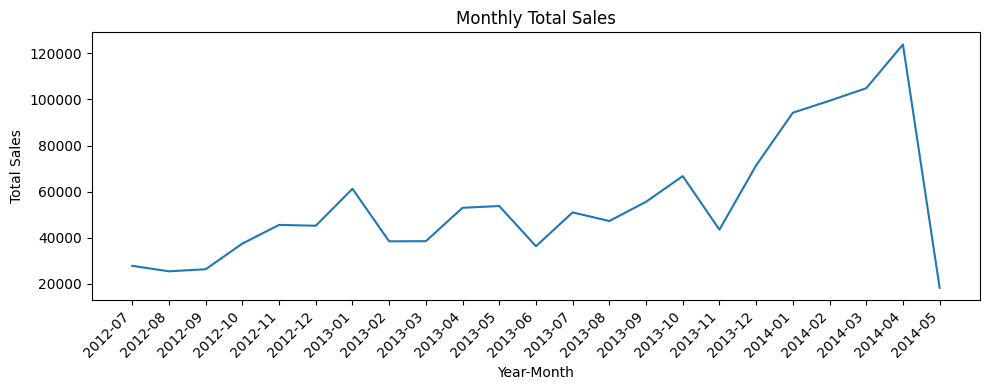

In [116]:
# Plot monthly total sales
plt.figure(figsize=(10, 4))
plt.plot(df_sales_by_month['YearMonth'], df_sales_by_month['TotalSales'])
plt.title('Monthly Total Sales')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Exercises

### Exercise 1 – Basic count per customer

**Goal:**
- For each customer, count how many orders they have placed.
- Return columns: `CustomerId`, `CompanyName`, `OrderCount`.
- Sort by `OrderCount` descending and show the top 10.

**Hints:**
- Join `Order` with `Customer` on `Order.CustomerId = Customer.Id`.
- Use `COUNT(*)` and `GROUP BY`.

After getting the DataFrame, just inspect it with `.head()` (no plot needed yet).

In [117]:
sql_ex1 = """
SELECT 
    c.Id AS CustomerId,
    c.CompanyName,
    COUNT(*) AS OrderCount
FROM "Order" o
JOIN Customer c ON o.CustomerId = c.Id
GROUP BY c.Id, c.CompanyName
ORDER BY OrderCount DESC
LIMIT 10;
"""

df_ex1 = pd.read_sql_query(sql_ex1, conn)
df_ex1

,CustomerId,CompanyName,OrderCount
0,SAVEA,Save-a-lot Markets,31
1,ERNSH,Ernst Handel,30
2,QUICK,QUICK-Stop,28
3,FOLKO,Folk och fä HB,19
4,HUNGO,Hungry Owl All-Night Grocers,19
5,BERGS,Berglunds snabbköp,18
6,HILAA,HILARION-Abastos,18
7,RATTC,Rattlesnake Canyon Grocery,18
8,BONAP,Bon app,17
9,FRANK,Frankenversand,15


### Exercise 2 – Average freight cost by ship country

**Goal:**
- For each `ShipCountry`, compute the **average freight**.
- Return columns: `ShipCountry`, `AvgFreight`.
- Sort by `AvgFreight` descending.
- Plot the top 10 countries as a bar chart.

**Hints:**
- Only the `Order` table is needed.
- Use `AVG(Freight)` and `GROUP BY ShipCountry`.
- Use a bar chart similar to the earlier examples.

In [118]:
# TODO: Exercise 2
sql_ex2 = """
-- Your SQL here
SELECT ShipCountry , AVG(Freight) AS AvgFreight
FROM "Order"
GROUP BY ShipCountry
ORDER BY AvgFreight DESC
"""

df_ex2 = pd.read_sql_query(sql_ex2, conn)
df_ex2.head()


,ShipCountry,AvgFreight
0,Austria,184.787500
1,Ireland,145.012632
2,USA,112.879426
3,Germany,92.485902
4,Sweden,87.502703


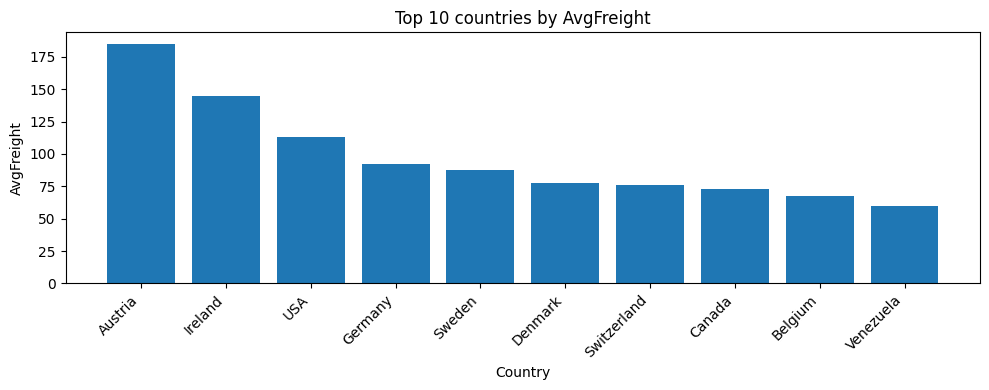

In [119]:
# Plot top 10 countries by AvgFreight
top_n = 10
df_freight = df_ex2.head(top_n)

plt.figure(figsize=(10, 4))
plt.bar(df_freight['ShipCountry'], df_freight['AvgFreight'])
plt.title(f'Top {top_n} countries by AvgFreight')
plt.xlabel('Country')
plt.ylabel('AvgFreight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exercise 3 – Total sales per employee

**Goal:**
- Compute **total sales** per employee.
- Use `LineTotal = UnitPrice * Quantity * (1 - Discount)`.
- Return columns: `EmployeeId`, full employee name (e.g. `FirstName || ' ' || LastName`), `TotalSales`.
- Sort by `TotalSales` descending and plot a bar chart of all employees.

**Hints:**
- Join `Order` with `OrderDetail` and `Employee`.
- Group by `Employee.Id` and name.
- Use a bar chart similar to the customer one.

In [120]:
# TODO: Exercise 3
sql_ex3 = """
-- Your SQL here
SELECT e.Id AS EmployeeId , e.FirstName || ' ' || e.LastName AS EmployeeName, SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
JOIN Employee e ON o.EmployeeId = e.Id
GROUP BY e.Id, EmployeeName
ORDER BY TotalSales DESC
"""

df_ex3 = pd.read_sql_query(sql_ex3, conn)
df_ex3



,EmployeeId,EmployeeName,TotalSales
0,4,Margaret Peacock,232890.8460
1,3,Janet Leverling,202812.8430
2,1,Nancy Davolio,192107.6045
3,2,Andrew Fuller,166537.7550
4,8,Laura Callahan,126862.2775
5,7,Robert King,124568.2350
6,9,Anne Dodsworth,77308.0665
7,6,Michael Suyama,73913.1295
8,5,Steven Buchanan,68792.2825


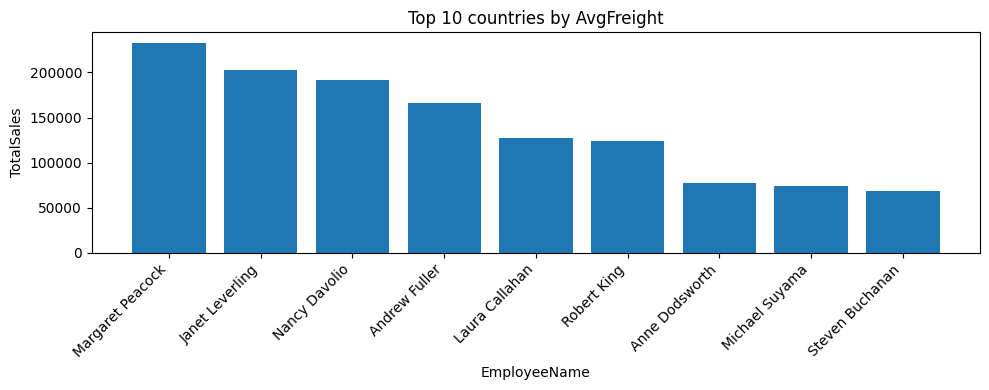

In [121]:
# Plot top 10 countries by AvgFreight
top_n = 10
employee_totalsales = df_ex3.head(top_n)

plt.figure(figsize=(10, 4))
plt.bar(employee_totalsales['EmployeeName'], employee_totalsales['TotalSales'])
plt.title(f'Top {top_n} countries by AvgFreight')
plt.xlabel('EmployeeName')
plt.ylabel('TotalSales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exercise 4 – Monthly sales trend for a specific country

**Goal:**
- Choose a single customer `Country` (e.g. `'Germany'`).
- Compute **monthly total sales** (`YearMonth`) for orders shipped to customers in that country.
- Plot a line chart of `YearMonth` vs `TotalSales`.

**Hints:**
- Similar to the monthly example, but join with `Customer` and filter on `Customer.Country`.
- Use `strftime('%Y-%m', o.OrderDate)` as `YearMonth`.
- You can either hard-code the country in SQL or pass it as a parameter in `params=[...]`.

In [124]:
sql_sales_by_month_germany = """
SELECT 
    strftime('%Y-%m', o.OrderDate) AS YearMonth,
    SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
JOIN Customer c ON o.CustomerId = c.Id
WHERE c.Country = 'Germany'
GROUP BY YearMonth
ORDER BY YearMonth;
"""

df_sales_by_month_germany = pd.read_sql_query(sql_sales_by_month, conn)
df_sales_by_month_germany



,YearMonth,TotalSales
0,2012-07,27861.8950
1,2012-08,25485.2750
2,2012-09,26381.4000
3,2012-10,37515.7250
4,2012-11,45600.0450
5,2012-12,45239.6300
6,2013-01,61258.0700
7,2013-02,38483.6350
8,2013-03,38547.2200
9,2013-04,53032.9525


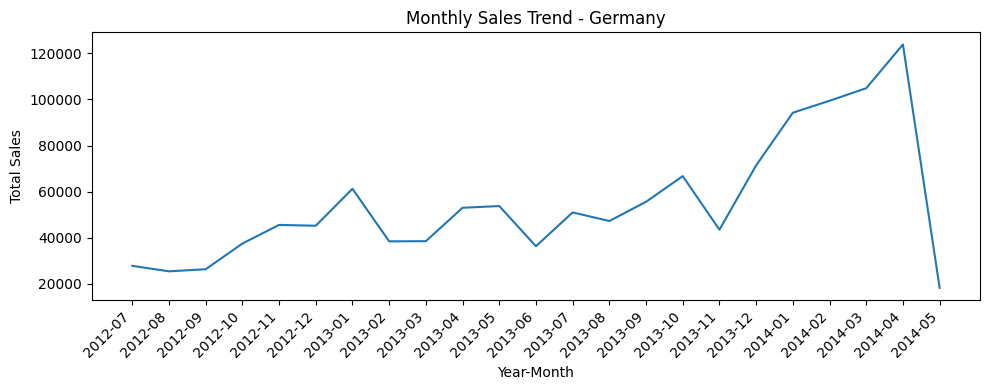

In [135]:
plt.figure(figsize=(10, 4))
plt.plot(df_sales_by_month_germany['YearMonth'], df_sales_by_month_germany['TotalSales'])
plt.title('Monthly Sales Trend - Germany')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exercise 5 – Customer lifetime value summary

**Goal:**
For each customer, compute:
- `FirstOrderDate`
- `LastOrderDate`
- `TotalSales` (sum of all LineTotals)

Return columns: `CustomerId`, `CompanyName`, `FirstOrderDate`, `LastOrderDate`, `TotalSales`.
Sort by `TotalSales` descending and inspect the top customers.

**Hints:**
- Use `MIN(o.OrderDate)` and `MAX(o.OrderDate)` along with `SUM(LineTotal)`.
- Join `Order`, `OrderDetail`, `Customer`.
- `GROUP BY` customer.

In [132]:
sql_FirstOrderDate_LastOrderDate = """
SELECT 
    c.Id AS CustomerId,c.CompanyName, MIN(o.OrderDate) AS FirstOrderDate,MAX(o.OrderDate) AS LastOrderDate,
    SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
JOIN Customer c ON o.CustomerId = c.Id
GROUP BY c.Id , c.CompanyName
"""

df_sales_by_FirstOrderDate_LastOrderDate = pd.read_sql_query(sql_FirstOrderDate_LastOrderDate, conn)
df_sales_by_FirstOrderDate_LastOrderDate

,CustomerId,CompanyName,FirstOrderDate,LastOrderDate,TotalSales
0,ALFKI,Alfreds Futterkiste,2013-08-25,2014-04-09,4273.0000
1,ANATR,Ana Trujillo Emparedados y helados,2012-09-18,2014-03-04,1402.9500
2,AROUT,Around the Horn,2012-11-15,2014-04-10,13390.6500
3,BERGS,Berglunds snabbköp,2012-08-12,2014-03-04,24927.5775
4,BLAUS,Blauer See Delikatessen,2013-04-09,2014-04-29,3239.8000
...,...,...,...,...,...
80,WARTH,Wartian Herkku,2012-07-26,2014-04-15,15648.7025
81,WELLI,Wellington Importadora,2012-07-15,2014-03-09,6068.2000
82,WHITC,White Clover Markets,2012-07-31,2014-05-01,27363.6050
83,WILMK,Wilman Kala,2013-07-30,2014-04-07,3161.3500


### Exercise 6 – Average order value by customer country

**Goal:**
- For each **customer country**, compute the **average order value**.
- Define order value as the sum of `LineTotal` over all lines in that order.
- Then average that per country.
- Plot the top 10 countries by average order value.

**Hints:**
- This is a **two-level aggregation**:
  1. First get `OrderValue` per order (group by `Order.Id`).
  2. Then join with `Customer` and compute average per `Country`.
- Use a subquery or CTE to structure your SQL.

In [134]:
sql_Average_order_value = """
SELECT c.Country , AVG(ov.OrderValue) AS AvgOrderValue
FROM(
SELECT o.Id AS OrderId, o.CustomerId, SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS OrderValue
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
GROUP BY o.Id, o.CustomerId
) ov
JOIN Customer c ON ov.CustomerId = c.Id
GROUP BY c.Country
ORDER BY AvgOrderValue DESC
LIMIT 10;
"""

df_sql_Average_order_value = pd.read_sql_query(sql_Average_order_value, conn)
df_sql_Average_order_value

,Country,AvgOrderValue
0,Austria,3200.095963
1,Ireland,2630.521316
2,USA,2012.988611
3,Germany,1887.578963
4,Denmark,1814.501250
5,Belgium,1780.255526
6,Switzerland,1760.703278
7,Canada,1673.209667
8,Sweden,1472.841622
9,Venezuela,1235.013674


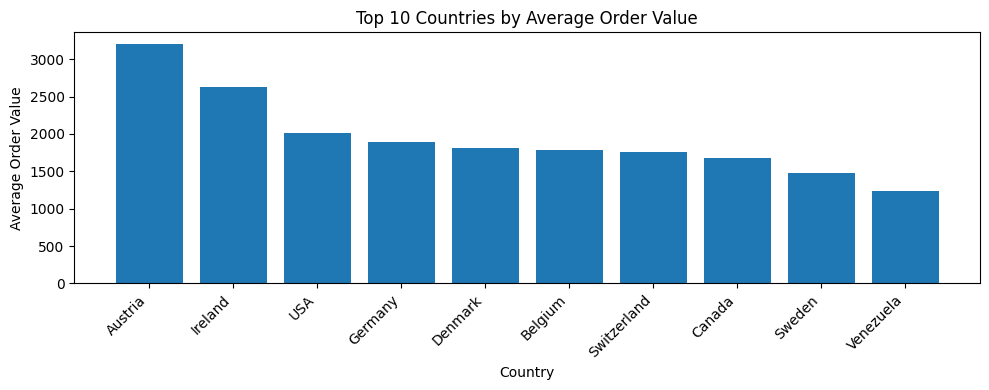

In [136]:
plt.figure(figsize=(10, 4))
plt.bar(df_sql_Average_order_value['Country'], df_sql_Average_order_value['AvgOrderValue'])
plt.title('Top 10 Countries by Average Order Value')
plt.xlabel('Country')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exercise 7 – Discount analysis by employee

**Goal:**
- For each employee, compute:
  - `TotalSales`
  - `AvgDiscount` (average discount over all their order lines)
- Return columns: `EmployeeId`, employee name, `TotalSales`, `AvgDiscount`.
- Sort primarily by `TotalSales` descending.

**Hints:**
- Join `Order` + `OrderDetail` + `Employee`.
- `AVG(Discount)` and `SUM(LineTotal)` in the same `GROUP BY`.

In [137]:
sql_Discount_analysis  = """
SELECT 
    e.Id AS EmployeeId , AVG(Discount) AS AvgDiscount, SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
JOIN Employee e ON o.EmployeeId = e.Id
GROUP BY EmployeeId 
ORDER BY TotalSales DESC 
"""

df_Discount_analysis = pd.read_sql_query(sql_Discount_analysis, conn)
df_Discount_analysis

,EmployeeId,AvgDiscount,TotalSales
0,4,0.061310,232890.8460
1,3,0.049688,202812.8430
2,1,0.049246,192107.6045
3,2,0.043776,166537.7550
4,8,0.056154,126862.2775
5,7,0.073580,124568.2350
6,9,0.068224,77308.0665
7,6,0.054464,73913.1295
8,5,0.066667,68792.2825


### Exercise 8 – Year-over-year sales trend

**Goal:**
- Compute **total sales per year** (calendar year).
- Plot a line chart of `Year` vs `TotalSales`.

**Hints:**
- Use `strftime('%Y', o.OrderDate)` to extract the year.
- Group by `Year`.
- Similar idea to the monthly plot, but with years.

In [140]:
sql_sales_by_year = """
SELECT
  strftime('%Y', o.OrderDate) AS Year,
  SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
GROUP BY Year
ORDER BY Year;
"""

df_sales_by_year = pd.read_sql_query(sql_sales_by_year, conn)
df_sales_by_year.head()

,Year,TotalSales
0,2012,208083.9700
1,2013,617085.2035
2,2014,440623.8660


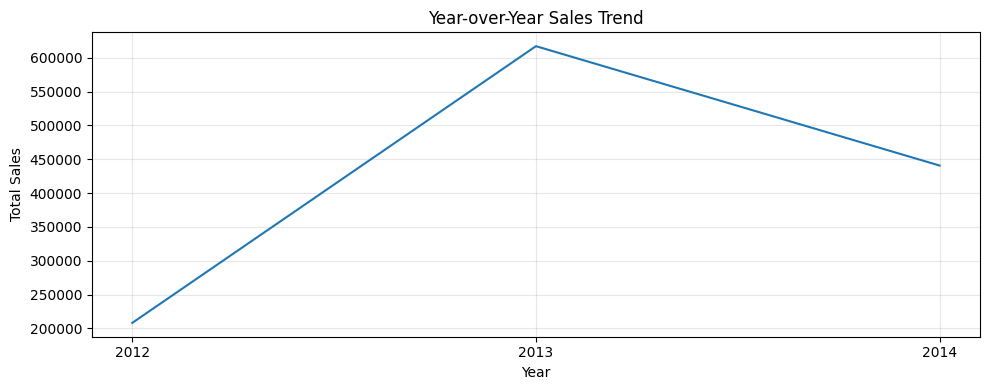

In [148]:
plt.figure(figsize=(10, 4))
plt.plot(df_sales_by_year['Year'], df_sales_by_year['TotalSales'])
plt.title('Year-over-Year Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 9 – Customer acquisition cohorts (by first order year)

**Goal:**
- For each customer, find the **year of their first order** (`FirstOrderYear`).
- Then, for each `FirstOrderYear`, compute:
  - Number of customers acquired
  - Total sales from those customers (across all years)

Return columns: `FirstOrderYear`, `CustomerCount`, `TotalSales`.

**Hints:**
- First, create a subquery that finds `MIN(OrderDate)` per `CustomerId` and extracts the year.
- Then join that with aggregated sales per customer (or join back to order lines).
- Group by `FirstOrderYear`.

In [160]:
sql_Customer_acquisition_cohorts = """
SELECT strftime('%Y', mo.mn_Date) AS FirstOrderYear , COUNT(DISTINCT mo.CustomerId) AS CustomerCount, SUM(mo.TotalSales) AS TotalSales
FROM(
SELECT  o.CustomerId , MIN(OrderDate) AS mn_Date, SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
GROUP BY o.CustomerId
) mo
GROUP BY
    FirstOrderYear
ORDER BY
    FirstOrderYear;
"""

df_sql_Customer_acquisition_cohorts = pd.read_sql_query(sql_Customer_acquisition_cohorts, conn)
df_sql_Customer_acquisition_cohorts

,FirstOrderYear,CustomerCount,TotalSales
0,2012,67,1.163223e+06
1,2013,21,1.005781e+05
2,2014,1,1.992050e+03


### Exercise 10 – Sales heatmap by year and country (advanced)

**Goal:**
- Build a table of **total sales** by `(Year, Country)`.
- Pivot it into a matrix (rows = Year, columns = Country) in pandas.
- Visualize it as a simple heatmap using `plt.imshow`.

**Hints:**
- In SQL:
  - Extract `Year` with `strftime('%Y', o.OrderDate)`.
  - Group by `Year` and `Country` (from `Customer` or `Order.ShipCountry`).
- In pandas:
  - Use `pivot_table(index='Year', columns='Country', values='TotalSales', fill_value=0)`.
  - Then plot with `plt.imshow` and add a colorbar.

In [165]:
sql_sales_by_year_and_country = """
SELECT
  strftime('%Y', o.OrderDate) AS Year,
  c.Country,
  SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)) AS TotalSales
FROM "Order" o
JOIN OrderDetail od ON o.Id = od.OrderId
JOIN Customer c ON o.CustomerId = c.Id
GROUP BY Year, c.Country
"""

df_sql_sales_by_year_and_country  = pd.read_sql_query(sql_sales_by_year_and_country , conn)
df_sql_sales_by_year_and_country

,Year,Country,TotalSales
0,2012,Austria,25601.345
1,2012,Belgium,6306.700
2,2012,Brazil,10937.920
3,2012,Canada,7372.680
4,2012,Denmark,2952.400
...,...,...,...
57,2014,Sweden,20398.230
58,2014,Switzerland,9147.115
59,2014,UK,22623.535
60,2014,USA,92633.673


In [168]:
pivot_table = df_sql_sales_by_year_and_country.pivot_table(index='Year', columns='Country', values='TotalSales', fill_value=0)
top_countries = df_sql_sales_by_year_and_country.groupby('Country')['TotalSales'].sum().nlargest(10).index
pivot_sales_top = pivot_table[top_countries]

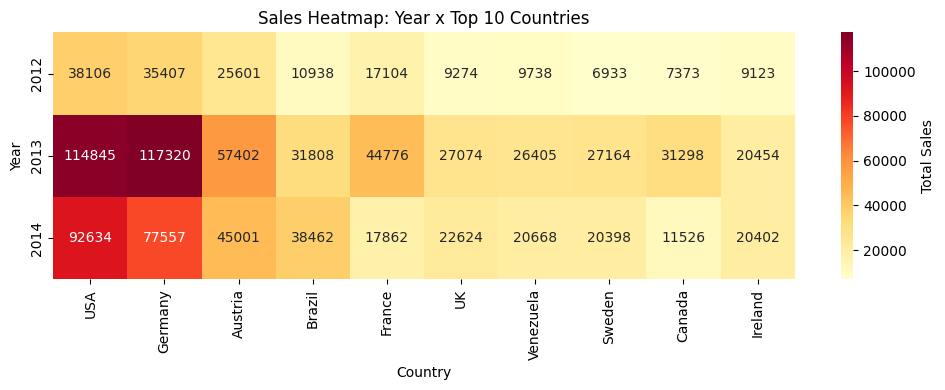

In [171]:
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_sales_top, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Total Sales'})
plt.title('Sales Heatmap: Year x Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Year')
plt.tight_layout()
plt.show()